<h1>TH1 与 TF1 的积分：定义与实例</h1><p>直方图保存每个 bin 的内容，函数描述连续曲线。计算峰区计数时，两者的积分需要使用相同区间和相同归一化。本页先用一个可手算的例子说明，再用峰加本底的谱作比较。</p><h2>1. Bin content、区间与积分</h2><p>下面人为设置 12 个 bin 的高度，用来检查积分定义，不把这些高度解释成一次 Poisson 计数实验。</p>

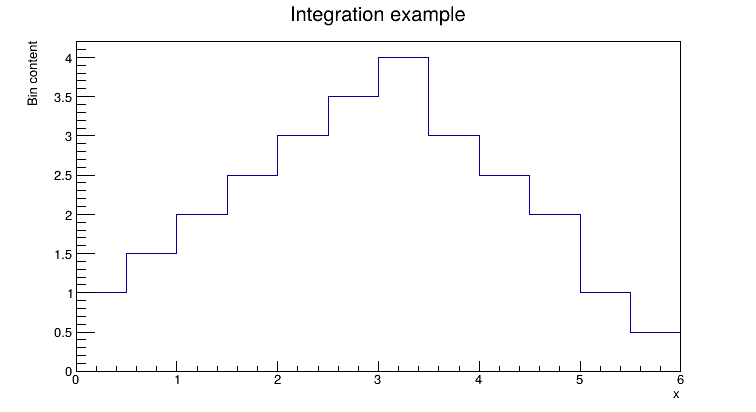

In [2]:
TCanvas *c1 = new TCanvas("c1", "Histogram and function", 760, 440);
TH1D *h = new TH1D("h", "Integration example;x;Bin content", 12, 0, 6);
double height[12] = {1,1.5,2,2.5,3,3.5,4,3,2.5,2,1,0.5};
for (int bin=1; bin<=12; ++bin) h->SetBinContent(bin, height[bin-1]);
h->SetBinContent(0, 1);   // underflow
h->SetBinContent(13, 2);  // overflow
h->SetStats(0);
h->SetMinimum(0);
h->Draw("hist");
c1->Draw();

<p>普通 bin 编号为 1 到 N；0 和 N+1 是 underflow、overflow。bin 包含左边界，不包含右边界。默认积分只包含普通 bin；若要包含溢出内容，应显式给出相应编号。</p>

In [4]:
int firstBin = 1, lastBin = 7;
double xmin = h->GetBinLowEdge(firstBin);
double xmax = h->GetBinLowEdge(lastBin)+h->GetBinWidth(lastBin);
cout << "Bin 7: center=" << h->GetBinCenter(7)
     << ", content=" << h->GetBinContent(7) << endl;
cout << "Bins 1..7 cover [" << xmin << ", " << xmax << ")" << endl;
cout << "Sum of contents = " << h->Integral(firstBin,lastBin) << endl;
cout << "Height times width = " << h->Integral(firstBin,lastBin,"width") << endl;
cout << "All bins including flows = " << h->Integral(0,13) << endl;

Bin 7: center=3.25, content=4
Bins 1..7 cover [0, 3.5)
Sum of contents = 17.5
Height times width = 8.75
All bins including flows = 29.5

<h2>2. 连续函数积分与 bin width</h2><p>前七个 bin 的中心值恰好落在 f(x)=0.75+x 上。将函数与直方图叠加，比较同一个完整 bin 区间。这里 f 表示每个等宽 bin 的高度，所以函数积分还要除以 bin width，才能与 bin content 的和比较。</p>

TH1 sum = 17.5
TF1 integral / bin width = 17.5

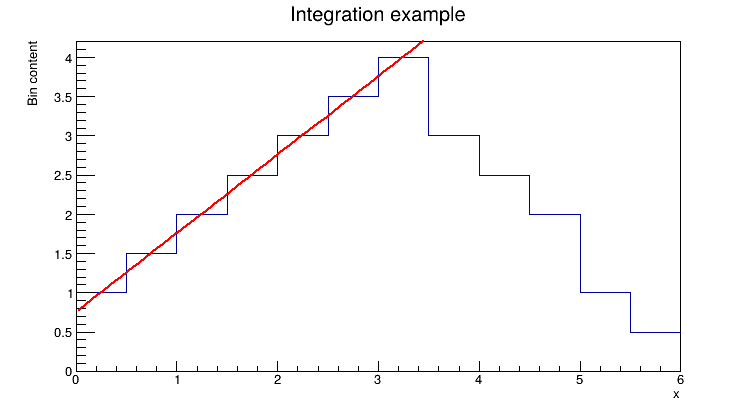

In [6]:
TF1 *f = new TF1("f", "0.75+x", 0, 6);
f->SetLineColor(kRed);
h->Draw("hist");
f->Draw("same");
c1->Draw();
double width = h->GetBinWidth(1);
cout << "TH1 sum = " << h->Integral(firstBin,lastBin) << endl;
cout << "TF1 integral / bin width = " << f->Integral(xmin,xmax)/width << endl;

<p>若函数本身表示计数密度（例如 counts/MeV），直接积分就是计数，不再除以 bin width。<code>Integral("width")</code> 则是把每个 bin content 乘以宽度后累加。变宽 bin 不能统一除以一个宽度。</p><h3>从坐标区间找到完整 bin</h3><p>例如希望考察 [0,3.4]，3.4 落在 [3.0,3.5) 这个 bin 内。直方图无法告诉我们该 bin 内有多少事例位于 3.4 以下。本例选择纳入整个 bin，因此实际比较区间为 [0,3.5)。若要求精确坐标 cut，应回到逐事例数据。</p>

In [8]:
double requestedMax = 3.4;
int endBin = h->FindBin(requestedMax);
double coveredMax = h->GetBinLowEdge(endBin)+h->GetBinWidth(endBin);
cout << "Requested upper edge=" << requestedMax << ", covered edge=" << coveredMax << endl;
cout << "TH1=" << h->Integral(1,endBin)
     << ", TF1/width=" << f->Integral(0,coveredMax)/width << endl;

Requested upper edge=3.4, covered edge=3.5
TH1=17.5, TF1/width=17.5

<h2 id="signal-example">3. 积分实例：峰与线性本底</h2><p>模拟一个 Gaussian 峰叠加在线性本底上的计数谱。signal 和 background 分别产生 2000 和 100000 个事例。函数形状先按这些计数及 bin width 归一化，因此图中的函数高度可直接与直方图比较。</p>

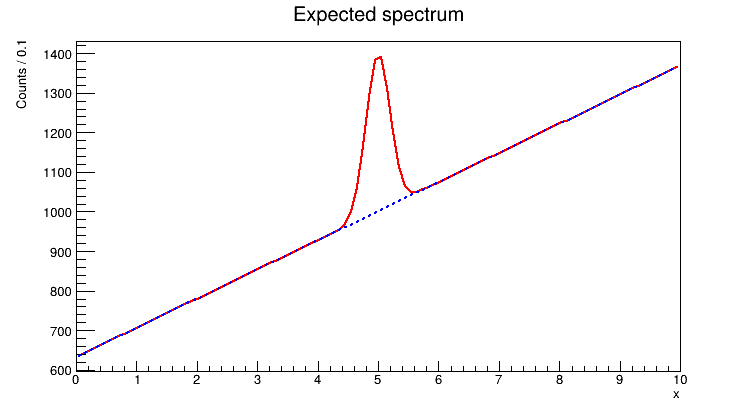

In [10]:
const double binWidth = 0.1;
TF1 *fB = new TF1("fB", "pol1", 0, 10);
TF1 *fS = new TF1("fS", "gaus", 0, 10);
fB->SetParameters(600,70);
double scaleB = 100000*binWidth/fB->Integral(0,10);
fB->SetParameters(600*scaleB,70*scaleB);
fS->SetParameters(2000*binWidth/(sqrt(2*TMath::Pi())*0.2),5,0.2);
TF1 *fSB = new TF1("fSB", "pol1(0)+gaus(2)", 0, 10);
fSB->SetParameters(fB->GetParameter(0),fB->GetParameter(1),fS->GetParameter(0),5,0.2);
fSB->SetTitle("Expected spectrum;x;Counts / 0.1");
fSB->Draw();
fB->SetLineColor(kBlue); fB->SetLineStyle(2); fB->Draw("same");
fS->SetLineColor(kGreen+2); fS->Draw("same");
c1->Draw();

<p><code>FillRandom</code> 按函数的形状抽样；第二个参数决定生成的事例数。保存两部分独立直方图只是为了在模拟中检查答案，真实实验只观测到它们的总谱。</p>

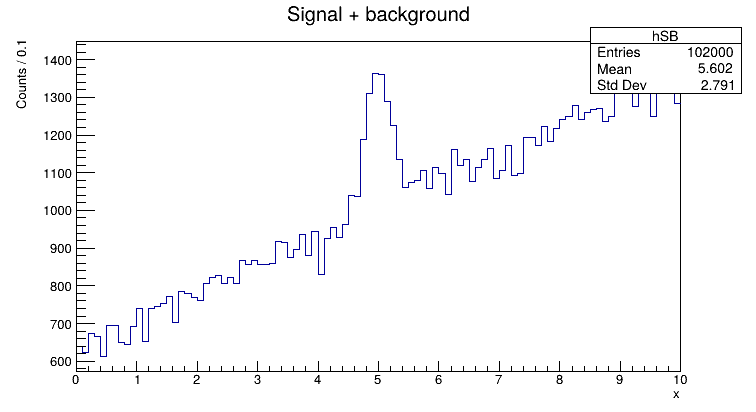

In [12]:
TH1D *hB = new TH1D("hB","Background",100,0,10);
TH1D *hS = new TH1D("hS","Signal",100,0,10);
TH1D *hSB = new TH1D("hSB","Signal + background;x;Counts / 0.1",100,0,10);
gRandom->SetSeed(1901);
hB->FillRandom("fB",100000);
hS->FillRandom("fS",2000);
hSB->Add(hB,hS);
hSB->Draw("hist");
c1->Draw();

<h3>联合拟合与分量提取</h3><p>在 [3.5,6.5] 内拟合 Gaussian + 线性本底，再将拟合参数交给两个分量函数。S 保存拟合结果，R 使用函数区间，I 按 bin 内的函数平均值比较计数。初值、sideband 与峰面积协方差的完整例子见 <a href="https://zhihuanli.github.io/Experimental-Method-in-Nuclear-Physics/tutorial/ROOT/ROOT_Tutorial_I_CPP.html">ROOT Tutorial I</a>。</p>

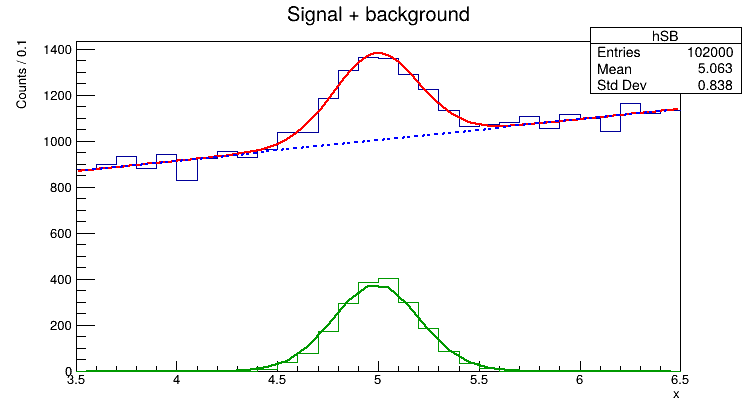

In [14]:
fSB->SetRange(3.5,6.5);
TFitResultPtr fitResult = hSB->Fit(fSB,"SRIQ");
if (int(fitResult)!=0 || !fitResult->IsValid()) throw runtime_error("Fit failed");
fB->SetParameters(fSB->GetParameter(0),fSB->GetParameter(1));
fS->SetParameters(fSB->GetParameter(2),fSB->GetParameter(3),fSB->GetParameter(4));
hSB->GetXaxis()->SetRangeUser(3.5,6.5);
hSB->SetMinimum(0); // 让单独的 signal 分量也能显示
hSB->Draw("hist");
fSB->Draw("same"); fB->Draw("same"); fS->Draw("same");
hS->SetLineColor(kGreen+2); hS->Draw("hist same");
c1->Draw();

<h3>在同一区间内比较计数</h3><p>下例以 bin 37 到 63 的完整边界定义积分区间，不把坐标上界误当作应包含的下一个 bin。比较：模拟已知 signal、拟合 signal 积分、总计数减拟合本底。后两种估计来自同一份数据，不是独立测量。</p>

In [16]:
int roiFirst=37, roiLast=63;
double lo=hSB->GetBinLowEdge(roiFirst);
double hi=hSB->GetBinLowEdge(roiLast)+hSB->GetBinWidth(roiLast);
double countError=0;
double totalCount=hSB->IntegralAndError(roiFirst,roiLast,countError);
double backgroundCount=fB->Integral(lo,hi)/binWidth;
double signalCount=fS->Integral(lo,hi)/binWidth;
cout << "ROI [" << lo << ", " << hi << ")" << endl;
cout << "Known signal = " << hS->Integral(roiFirst,roiLast) << endl;
cout << "Fitted signal = " << signalCount << endl;
cout << "Total - fitted background = " << totalCount-backgroundCount << endl;
cout << "Raw ROI counts = " << totalCount << " +/- " << countError << endl;

ROI [3.6, 6.3)
Known signal = 2000
Fitted signal = 2014.41
Total - fitted background = 2041.88
Raw ROI counts = 29001 +/- 170.297

<p><code>IntegralAndError</code> 按已存储的 bin errors 传播求和误差，假定不同 bin 不相关。最后打印的是总谱 ROI 计数误差，不是扣本底后的净计数误差。拟合峰面积还需传播拟合参数的 covariance；不能把总谱与同一数据拟合出的本底当成独立量直接相加误差。</p><p>参考：<a href="https://root.cern.ch/doc/master/classTH1.html">TH1::Integral / IntegralAndError</a> · <a href="https://root.cern.ch/doc/master/classTF1.html">TF1::Integral / IntegralError</a>。</p>